In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score, precision_score

In [ ]:
#Load the dataset
df=pd.read_csv('/content/drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
df.shape

(200, 6)

In [ ]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
print("No of duplicate rows:",df.duplicated().sum())

No of duplicate rows: 0


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [ ]:
# Feature summary panel
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
print("Feature Summary:\n")
print("Numerical Features:")
for col in numerical_features:
    print("-", col)
print("\nCategorical Features:")
for col in categorical_features:
    print("-", col)

Feature Summary:

Numerical Features:
- Age
- Na_to_K

Categorical Features:
- Sex
- BP
- Cholesterol
- Drug


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# List of actual categorical columns in df to be encoded
categorical_cols = ['Sex', 'BP', 'Cholesterol', 'Drug']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [ ]:
# Target Column Encoding
# The 'Drug' column is the target and has already been encoded by LabelEncoder in the previous step.
print("Target column 'Drug' is already encoded.")

Target column 'Drug' is already encoded.


In [ ]:
# Separate features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print("Features (X) and target (y) separated successfully")

Features (X) and target (y) separated successfully


In [ ]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [ ]:
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (160, 5)
Testing set size: (40, 5)


In [ ]:
#model building
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
#predictions on test data
y_pred=model.predict(x_test)

In [ ]:
#evaluation metrics
confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 5  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 18]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40

0.975


In [ ]:
# Training Accuracy
train_accuracy = model.score(x_train, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 100.00%
Testing Accuracy: 97.50%


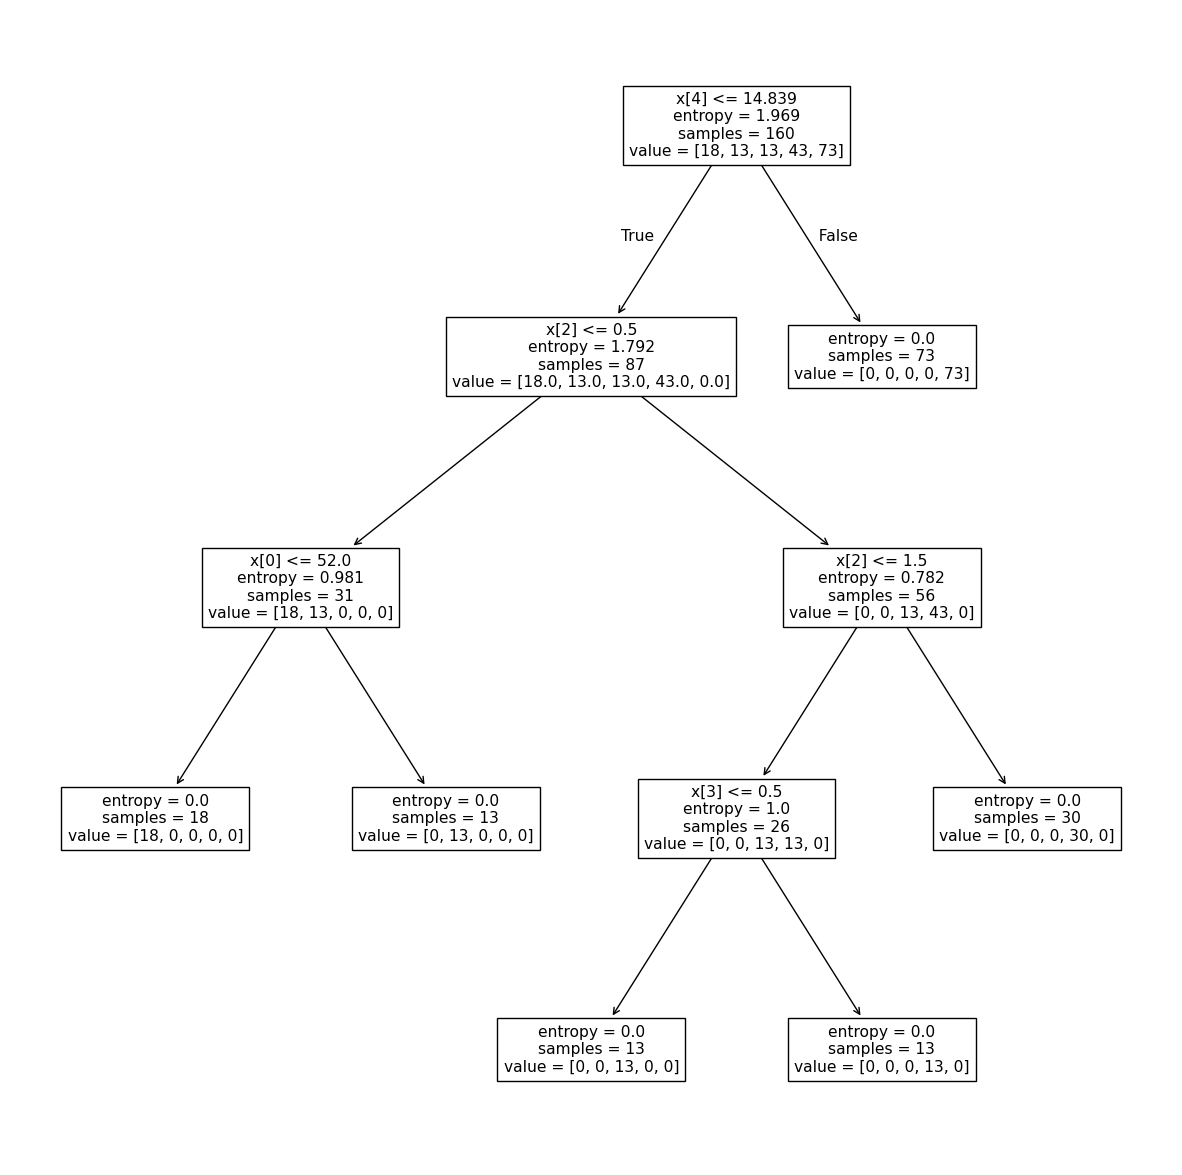

In [ ]:
#display decision tree
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(model)
plt.show()

In [ ]:
#auc_roc_score
from sklearn.metrics import roc_auc_score

# Get probability estimates for each class
y_pred_proba = model.predict_proba(x_test)

# Calculate AUC-ROC score for multi-class classification
# 'ovr' (One-vs-Rest) strategy is used, and 'weighted' averaging accounts for class imbalance.
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
print(f"AUC-ROC Score (weighted, OVR): {roc_auc:.4f}")

AUC-ROC Score (weighted, OVR): 0.9857


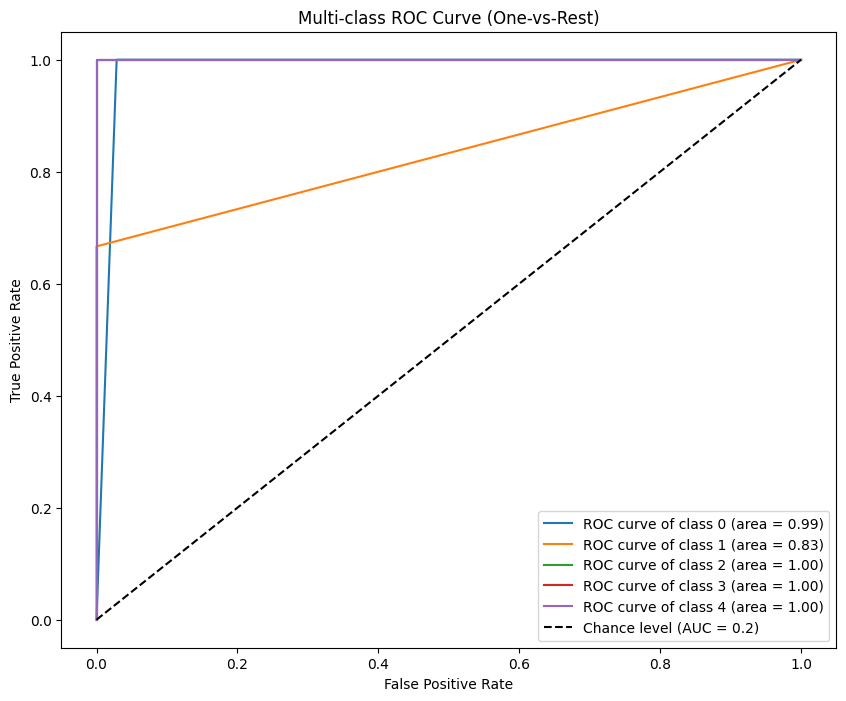

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the true labels for OvR strategy
n_classes = len(np.unique(y_test))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.2)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(False)
plt.show()